<a href="https://colab.research.google.com/github/Anshikasharma37/student-dropout-StrangerStrings/blob/main/model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving fully_transformed_student_dataset.csv to fully_transformed_student_dataset.csv


(4424, 35)
  Marital Status                  Application Mode  Application Order  \
0         Single      2nd phase—general contingent                  5   
1         Single  International student (bachelor)                  1   
2         Single      1st phase—general contingent                  5   
3         Single      2nd phase—general contingent                  2   
4        Married                 Over 23 years old                  1   

                           Course Name Daytime/Evening Attendance  \
0      Animation and Multimedia Design                    Daytime   
1                              Tourism                    Daytime   
2                 Communication Design                    Daytime   
3         Journalism and Communication                    Daytime   
4  Social Service (evening attendance)                    Evening   

  Previous Qualification Nationality            Mother's Qualification  \
0    Secondary education  Portuguese           General commer

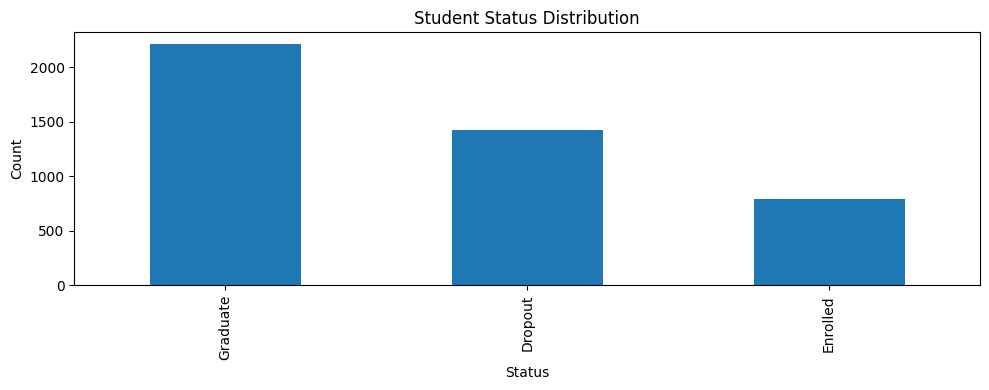

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('fully_transformed_student_dataset.csv')
print(df.shape)
print(df.head())

print(df['Student Status'].value_counts())
print(df['Student Status'].value_counts(normalize=True) * 100)

print(df.dtypes)
print(df.describe())

plt.figure(figsize=(10, 4))
df['Student Status'].value_counts().plot(kind='bar')
plt.title('Student Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Numerical columns (17)
Categorical columns (18)
Age < 20: Dropout rate = 20.95%
Age < 20: Dropout rate = 20.95%
Age < 20: Dropout rate = 20.95%
Average Grade (2nd Sem): -0.5718
Approved Units (2nd Sem): -0.5695
Average Grade (1st Sem): -0.4807
Approved Units (1st Sem): -0.4791
Age at Enrollment: 0.2542
Evaluated Units (2nd Sem): -0.1550
Enrolled Units (2nd Sem): -0.1415
Enrolled Units (1st Sem): -0.1246
Evaluated Units (1st Sem): -0.0901
Not Evaluated Units (2nd Sem): 0.0799


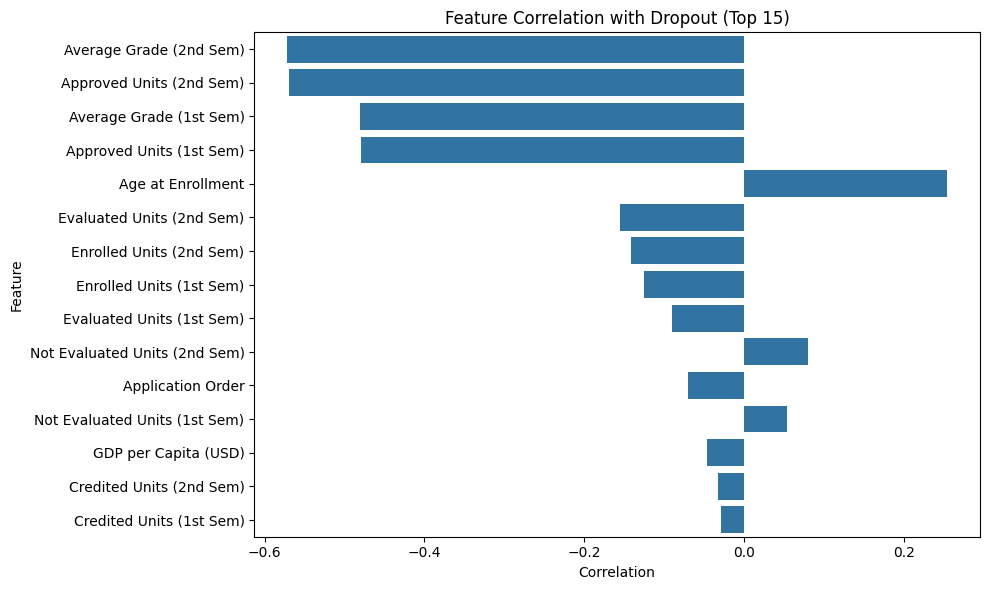

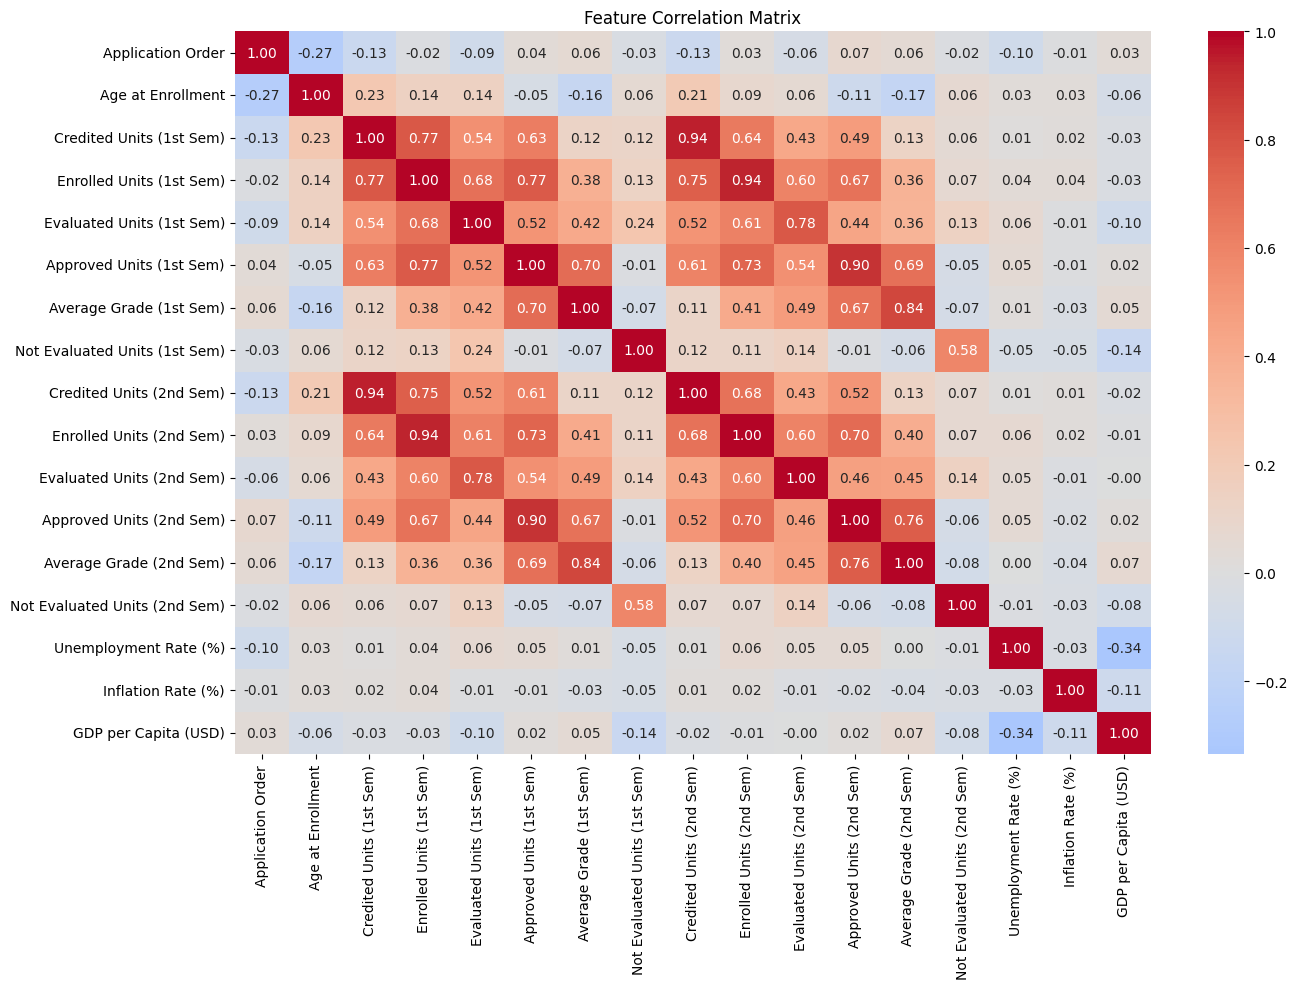

In [4]:
num_col = df.select_dtypes(include=[np.number]).columns.tolist()
catg_col = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns ({len(num_col)})")
print(f"Categorical columns ({len(catg_col)})")

# Academic Performance
for threshold in [6.0, 7.0, 8.0]:
    high_cgpa = df[df['Age at Enrollment'] < 20]
    if len(high_cgpa) > 0:
        dropout_rate = (high_cgpa['Student Status'] == 'Dropout').sum() / len(high_cgpa) * 100
        print(f"Age < 20: Dropout rate = {dropout_rate:.2f}%")


target_binary = (df['Student Status'] == 'Dropout').astype(int)

correlations = {}
for col in num_col:
    if col in df.columns and df[col].dtype in [np.float64, np.int64]:
        try:
            corr = df[col].corr(target_binary)
            correlations[col] = corr
        except:
            pass

sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for feature, corr in sorted_corr[:10]:
    print(f"{feature}: {corr:.4f}")

corr_df = pd.DataFrame(list(sorted_corr[:15]), columns=['Feature', 'Correlation'])
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df, x='Correlation', y='Feature')
plt.title('Feature Correlation with Dropout (Top 15)')
plt.tight_layout()
plt.show()

numerical_subset = df[num_col].select_dtypes(include=[np.number])
corr_matrix = numerical_subset.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [5]:

# ==================== OUTLIER DETECTION ====================


def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers

# Check for outliers in key features
key_features = ['Age at Enrollment', 'Average Grade (1st Sem)', 'Unemployment Rate (%)']
for feature in key_features:
    if feature in df.columns:
        outliers = detect_outliers_iqr(df, feature)
        print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%) errors_to_fix")

Age at Enrollment: 441 outliers (9.97%) errors_to_fix
Average Grade (1st Sem): 726 outliers (16.41%) errors_to_fix
Unemployment Rate (%): 0 outliers (0.00%) errors_to_fix


In [6]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold

# Initialize df_clean with the main DataFrame
df_clean = df.copy()

# Handling missing values (imputing missing values instead of dropping them with the median value of column)
for col in num_col:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed {col} with median: {median_val}")

for col in catg_col:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0] # [0] to get the first mode in case of multiple modes
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Imputed {col} with mode: {mode_val}")


def handle_outliers_capping(data, column, method='iqr'):
    if method == 'iqr':
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data[column] = data[column].clip(lower, upper)
    elif method == 'zscore':
        mean = data[column].mean()
        std = data[column].std()
        data[column] = data[column].clip(mean - 3*std, mean + 3*std)
    return data

# Apply to key features
outlier_cols = ['Age at Enrollment', 'Average Grade (1st Sem)', 'Average Grade (2nd Sem)',
                'Unemployment Rate (%)', 'Inflation Rate (%)', 'GDP per Capita (USD)']

for col in outlier_cols:
    if col in df_clean.columns:
        df_clean = handle_outliers_capping(df_clean, col, method='iqr')

# Feature engineering
if 'Average Grade (1st Sem)' in df_clean.columns and 'Average Grade (2nd Sem)' in df_clean.columns:
    df_clean['grade_trend'] = df_clean['Average Grade (2nd Sem)'] - df_clean['Average Grade (1st Sem)']
    print("✓ Created: grade_trend")

if 'Average Grade (1st Sem)' in df_clean.columns and 'Average Grade (2nd Sem)' in df_clean.columns:
    df_clean['sem_performance_ratio'] = np.where(
        df_clean['Average Grade (1st Sem)'] > 0,
        df_clean['Average Grade (2nd Sem)'] / df_clean['Average Grade (1st Sem)'],
        1
    )


# ENCODING CATEGORICAL VARIABLES

df_clean['Dropout_Binary'] = (df_clean['Student Status'] == 'Dropout').astype(int)

categorical_features_to_encode = [col for col in catg_col
                                   if col in df_clean.columns
                                   and df_clean[col].nunique() <= 10
                                   and col != 'Student Status']

df_clean = pd.get_dummies(df_clean, columns=categorical_features_to_encode, drop_first=True)
print(f"One-hot encoded {len(categorical_features_to_encode)} categorical features")


numeric_cols_final = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_final = [col for col in numeric_cols_final if col != 'Dropout_Binary']

X = df_clean[numeric_cols_final]
y = df_clean['Dropout_Binary']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# NORMALIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Features normalized using StandardScaler")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

✓ Created: grade_trend
One-hot encoded 9 categorical features
Features normalized using StandardScaler
Training set shape: (3539, 19)
Test set shape: (885, 19)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, recall_score, precision_score, roc_curve, auc
)


print("**** TRAINING BASELINE MODELS ****")

# 1. Logistic Regression
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
model_lr.fit(X_train_scaled, y_train)
print("!!! Logistic Regression Trained !!!")

# 2. Random Forest
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_scaled, y_train)
print("!!! Random Forest Trained !!!")


**** TRAINING BASELINE MODELS ****
!!! Logistic Regression Trained !!!
!!! Random Forest Trained !!!


In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]

    # Training metrics
    print(f"Accuracy:  {(y_train_pred == y_train).sum() / len(y_train):.4f}")
    print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
    print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_train, y_train_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_train, y_train_pred_proba):.4f}")

    # Test metrics
    accuracy = (y_test_pred == y_test).sum() / len(y_test)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_pred_proba)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

    print(classification_report(y_test, y_test_pred, target_names=['No Dropout', 'Dropout']))

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

# Evaluating models
results = []
results.append(evaluate_model(model_lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression'))
results.append(evaluate_model(model_rf, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest'))

# MODEL COMPARISON TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False)
print(results_df.to_string(index=False))




\n==================================================
Model: Logistic Regression
Accuracy:  0.8375
Precision: 0.7230
Recall:    0.8012
F1-Score:  0.7601
ROC-AUC:   0.8977
Accuracy:  0.8621
Precision: 0.7700
Recall:    0.8134
F1-Score:  0.7911
ROC-AUC:   0.9171
TN: 532, FP: 69
FN: 53, TP: 231
              precision    recall  f1-score   support

  No Dropout       0.91      0.89      0.90       601
     Dropout       0.77      0.81      0.79       284

    accuracy                           0.86       885
   macro avg       0.84      0.85      0.84       885
weighted avg       0.86      0.86      0.86       885

\n==================================================
Model: Random Forest
Accuracy:  0.9802
Precision: 0.9742
Recall:    0.9639
F1-Score:  0.9691
ROC-AUC:   0.9982
Accuracy:  0.8655
Precision: 0.8481
Recall:    0.7077
F1-Score:  0.7716
ROC-AUC:   0.8999
TN: 565, FP: 36
FN: 83, TP: 201
              precision    recall  f1-score   support

  No Dropout       0.87      0.94      0

In [9]:
import xgboost as xgb
# 3. XGBoost

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train_scaled, y_train, verbose=False)
print("!!!Trained!!!")

results.append(evaluate_model(model_xgb, X_train_scaled, X_test_scaled, y_train, y_test, 'XGBoost'))

# MODEL COMPARISON TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False)
print(results_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:31:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


!!!Trained!!!
\n==================================================
Model: XGBoost
Accuracy:  0.9658
Precision: 0.9269
Recall:    0.9701
F1-Score:  0.9480
ROC-AUC:   0.9945
Accuracy:  0.8588
Precision: 0.7870
Recall:    0.7676
F1-Score:  0.7772
ROC-AUC:   0.8993
TN: 542, FP: 59
FN: 66, TP: 218
              precision    recall  f1-score   support

  No Dropout       0.89      0.90      0.90       601
     Dropout       0.79      0.77      0.78       284

    accuracy                           0.86       885
   macro avg       0.84      0.83      0.84       885
weighted avg       0.86      0.86      0.86       885

         model_name  accuracy  precision   recall       f1  roc_auc
Logistic Regression  0.862147   0.770000 0.813380 0.791096 0.917136
            XGBoost  0.858757   0.787004 0.767606 0.777184 0.899320
      Random Forest  0.865537   0.848101 0.707746 0.771593 0.899859


In [10]:
from sklearn.model_selection import cross_validate, GridSearchCV

param_grid_xgb = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=2,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid_xgb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Searching best parameters...")
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

model_xgb_tuned = grid_search.best_estimator_

\n=== HYPERPARAMETER TUNING (XGBoost) ===
Searching best parameters...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:32:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.6}
Best CV F1 Score: 0.8375


In [16]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', model_rf),
        ('xgb', model_xgb_tuned),
        ('lr', model_lr),
    ],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train_scaled, y_train)
print("!!!Ensemble trained!!!")

results.append(evaluate_model(ensemble, X_train_scaled, X_test_scaled, y_train, y_test, 'ensemble'))

# MODEL COMPARISON TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False)
print(results_df.to_string(index=False))

!!!Ensemble trained!!!
\n==================================================
Model: ensemble
Accuracy:  0.9231
Precision: 0.8872
Recall:    0.8716
F1-Score:  0.8793
ROC-AUC:   0.9775
Accuracy:  0.8678
Precision: 0.8104
Recall:    0.7676
F1-Score:  0.7884
ROC-AUC:   0.9160
TN: 550, FP: 51
FN: 66, TP: 218
              precision    recall  f1-score   support

  No Dropout       0.89      0.92      0.90       601
     Dropout       0.81      0.77      0.79       284

    accuracy                           0.87       885
   macro avg       0.85      0.84      0.85       885
weighted avg       0.87      0.87      0.87       885

         model_name  accuracy  precision   recall       f1  roc_auc
Logistic Regression  0.862147   0.770000 0.813380 0.791096 0.917136
           ensemble  0.867797   0.810409 0.767606 0.788427 0.915953
           ensemble  0.867797   0.810409 0.767606 0.788427 0.915953
           ensemble  0.867797   0.835341 0.732394 0.780488 0.906075
            XGBoost  0.858757

\n=== SHAP EXPLAINABILITY ===
\nGenerating SHAP values (this may take a moment)...
✓ SHAP values generated


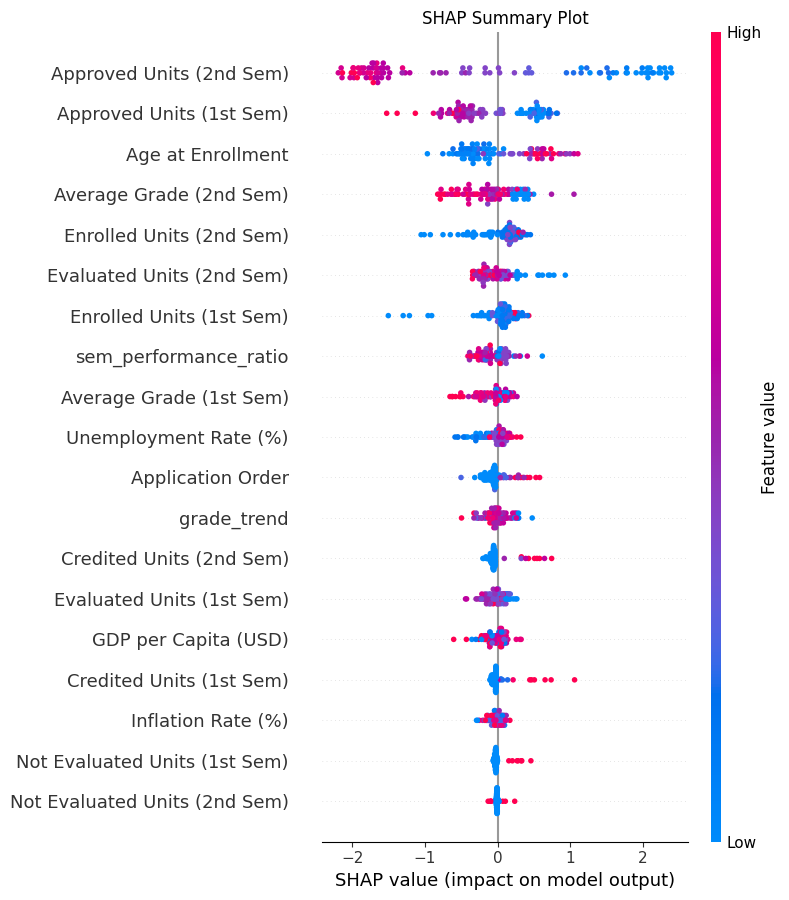

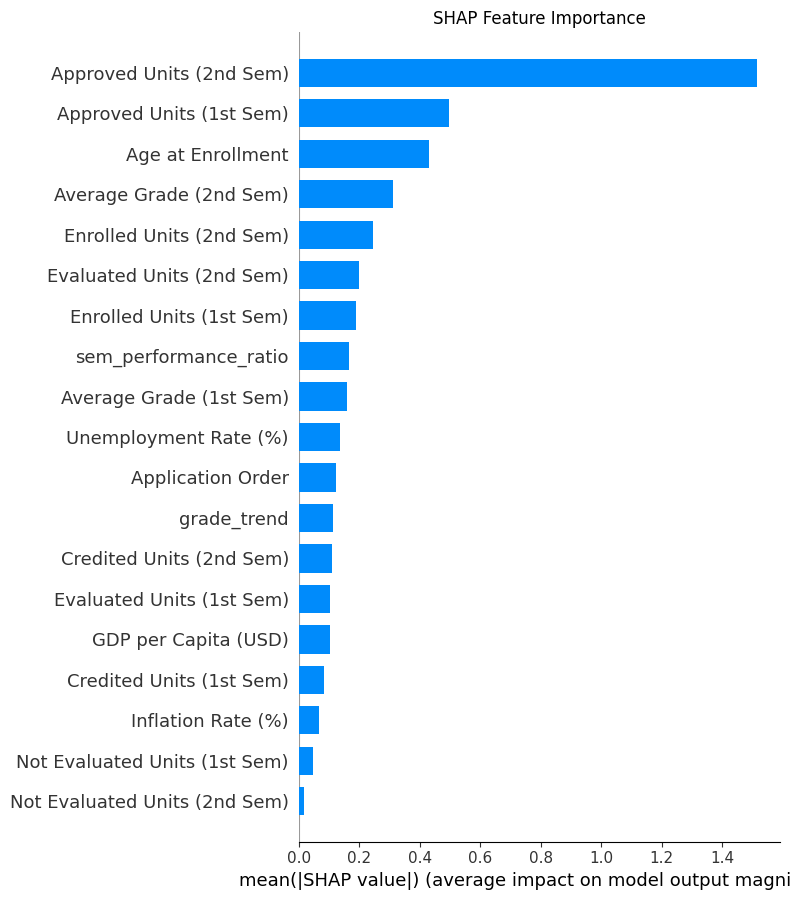

In [12]:
import shap

sample_size = min(100, len(X_test_scaled))
X_sample = X_test_scaled.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

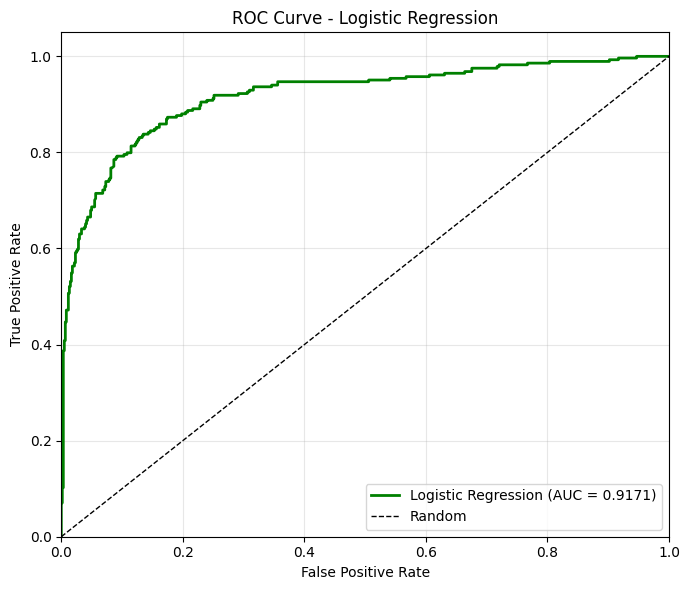

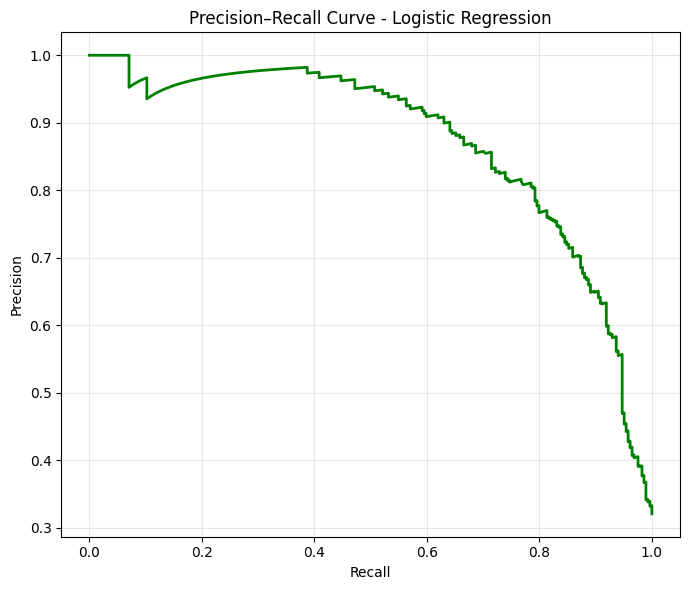

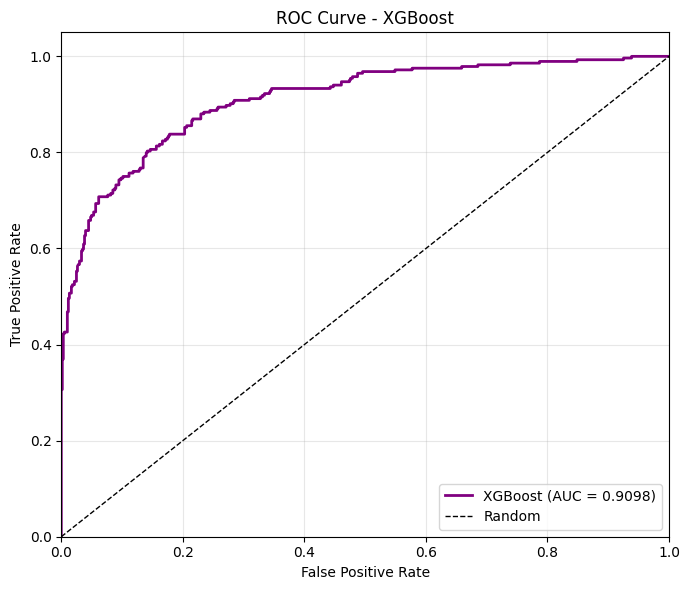

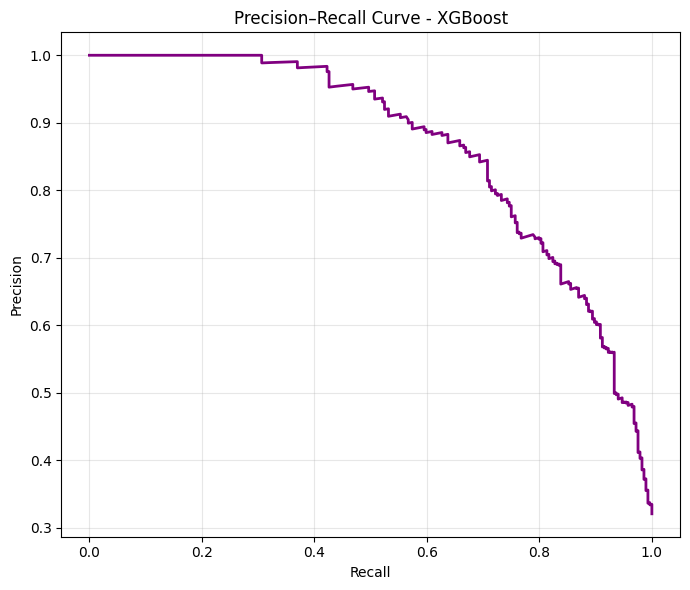

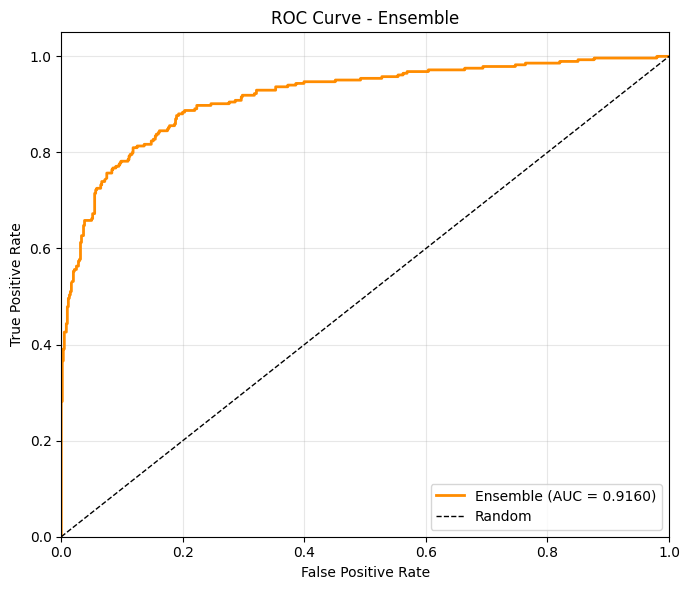

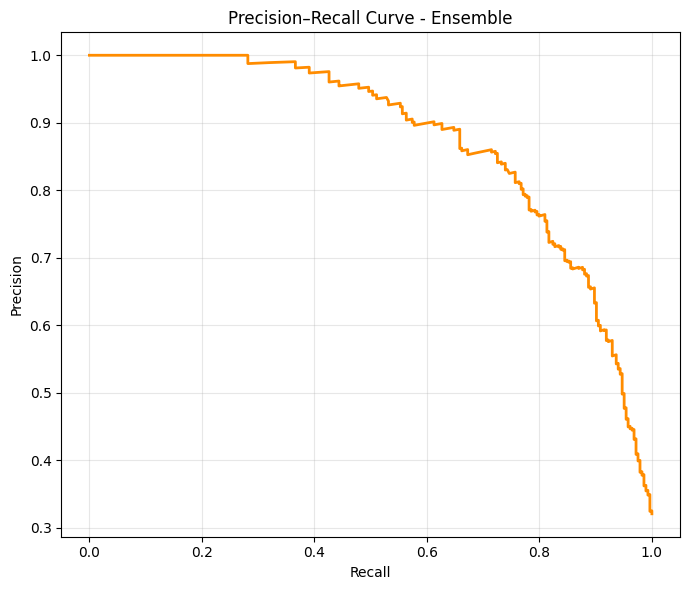

In [20]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

def plot_roc_pr(model, X_test, y_test, model_name, color):
    # Probabilities for positive class
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Precision–Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, color=color, lw=2, label=model_name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision–Recall Curve - {model_name}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Call for each model
plot_roc_pr(model_lr,  X_test_scaled, y_test, "Logistic Regression", "green")
plot_roc_pr(model_xgb_tuned, X_test_scaled, y_test, "XGBoost", "purple")
plot_roc_pr(ensemble, X_test_scaled, y_test, "Ensemble", "darkorange")
